# Crowdsourced Graduate Admissions Data: Patterns, Biases, and Predictive Limits

**CSC271H1 Final Project** | Sandesh Bhandari | March 28 2026

## Project Contents

<pre style="font-family: monospace; line-height: 1.5; font-size: 14px;">
<strong>PROJECT/</strong>
├── <span style="color: #3b82f6; font-weight: bold;">config.py</span>                                   - Global variables, typography settings, color palettes, and official admission rates.
├── <span style="color: #3b82f6; font-weight: bold;">data_processing.py</span>                          - Pandas code to clean raw scraped data, parse regex features, and handle NaNs.
├── <span style="color: #3b82f6; font-weight: bold;">database.py</span>                                 - SQLite schema creation, data insertion, and SQL queries.
├── <span style="color: #3b82f6; font-weight: bold;">plotting.py</span>                                 - Matplotlib and Seaborn visualization functions for all charts and figures.
├── <span style="color: #3b82f6; font-weight: bold;">predictive_modeling.py</span>                      - Logistic regression setup, Saerens prior adjustments, and associated plots.
├── <span style="color: #3b82f6; font-weight: bold;">scraper.py</span>                                  - Cloudscraper and BeautifulSoup code to scrap applicant records from GradCafe.
├── <span style="color: #f97316; font-weight: bold;">index.ipynb</span>                               - Primary Research Notebook.
├── <span style="color: #f97316; font-weight: bold;">web_scraping.ipynb</span>                          - Notebook demonstrating Web scraping process.
├── <span style="color: #10b981; font-weight: bold;">uoft_all_masters_decisions.csv</span>              - Raw scraped dataset of UofT Master's program decisions.
├── <span style="color: #10b981; font-weight: bold;">uoft_published_graduate_admissions_data.csv</span> - Official benchmark dataset for UofT.
├── <span style="color: #10b981; font-weight: bold;">upenn_all_masters_decisions.csv</span>             - Raw scraped dataset of UPenn Master's program decisions.
└── <span style="color: #10b981; font-weight: bold;">upenn_publicly_av_masters_admissions.csv</span>    - Official benchmark dataset for UPenn.
</pre>

## Notebook Contents

- Abstract
1. Introduction
2. Data Acquisition
   - 2.1 Web Scraping
   - 2.2 Cleaning and Normalization
   - 2.3 Official Admission Data
3. Analysis
   - 3.1 Relational Database
   - 3.2 SQL Queries
   - 3.3 GPA and Admission Probability
   - 3.4 Reporting Bias: GradCafe vs. Published Rates
   - 3.5 Trends Over Time
   - 3.6 GRE Submission and Outcomes
   - 3.7 UPenn Official Admissions Data
4. Predictive Modelling
   - 4.1 Motivation and Approach
   - 4.2 Logistic Regression Model
   - 4.3 Model Performance
   - 4.4 Results and Interpretation
5. Conclusions
6. Limitations
7. References

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import display, HTML

In [2]:
import config

## Abstract

This project examines whether self-reported graduate admissions data from TheGradCafe can meaningfully characterize admission dynamics at the University of Toronto and the University of Pennsylvania. The corresponding functions scrape, clean, and store the data in a normalized SQLite database, run seven SQL queries to characterize GPA distributions, acceptance rates by GPA range, and the association between GRE reporting and outcomes, and compare the platform's implied acceptance rates against official institutional figures compiled from public sources. A binary logistic regression is then trained to show that GPA and GRE together produce AUC of 0.5878 at UofT and 0.7008 at UPenn, confirming that quantitative metrics carry modest signal but cannot reliably predict individual outcomes. The gap between GradCafe's implied acceptance rates and official figures is the most practically significant finding.



## 1. Introduction

Every year, applicants to graduate school navigate admissions processes that are largely opaque. Most universities publish little or no data on selectivity at the program level, and the data that does exist is scattered across department websites and annual reports with no standard format. Into this information vacuum stepped a class of crowdsourced platforms where applicants voluntarily post their own results. The most prominent of these is [TheGradCafe](https://www.thegradcafe.com/), which has accumulated over two decades of self-reported admissions decisions across nearly every graduate program in North America.

The platform works as follows:
- a user submits their application outcome for a specific program and cycle, optionally attaching their GPA, GRE score, and a brief comment. 
- There is no verification. The database is searchable, and prospective applicants routinely consult it when deciding where to apply and what credentials are competitive. 
- It has real influence over application behavior despite having no institutional backing.

Based on the data obtained from the platform, this project thus investigates four main questions:

1. How does self-reported undergraduate GPA relate to admission probability at the University of Toronto and University of Pennsylvania?
2. Is there a meaningful difference in the GPA profiles of accepted applicants between the two schools, and does this reflect their actual selectivity?
3. Does submitting a GRE score correlate with higher acceptance rates in programs where the test is optional?
4. How well can GPA and GRE predict admission outcomes, and what can crowdsourced admission data tell us about the limits of quantitative prediction?

## 2. Data Acquisition

### 2.1 Web Scraping

TheGradCafe hosts its survey results through a Cloudflare-protected endpoint. Standard HTTP requests are blocked; scraping requires `cloudscraper`, a library that mimics a real browser's TLS handshake<sup>[1]</sup>. Requests are throttled with a random 2 to 5 second delay per page to avoid triggering rate limits<sup>[2]</sup>.

For each university, the scraper queries the survey with the school name and a Masters degree filter, then parses the returned HTML table. Each record spans three row types: a primary row with school, program, date, and decision; a tag row containing chip-style labels for GPA, GRE, season, and applicant status; and an optional comments row. Client-side filtering drops any row where the school name does not contain the target institution's distinctive keywords, preventing cross-contamination from similarly-named schools appearing in the same results.<br> Two CSVs were produced: <u>3,211</u> raw records for UofT and <u>1,730</u> for UPenn.

Web scraping takes a long time to complete. To maintain modularity and avoid redundant execution, the process is isolated in `web_scraping.ipynb`.

### 2.2 Cleaning and Normalization

**Decision label.** The raw decision field contains free-text strings such as *"Accepted on 6 Mar"*. A regex extracts the first word and maps it to a binary `Status_Binary` column (1 = accepted, 0 = rejected). Ambiguous entries like *Interview* and *Waitlisted* become NaN and are excluded from analyses requiring a decision.

**GPA.** Values like *GPA 3.80* are parsed by regex into a float. Values above 4.0 are set to NaN rather than retained, because these almost certainly come from schools which use different grade scale like 4.33, 10, 100 etc.

**GRE.** The first three-digit integer after the string *GRE* is extracted as `GRE_Total`. Because a large number of records include no GRE score, a boolean `GRE_Reported`  is created to flag and retain all rows rather than dropping on GRE missingness.

Rows missing both a valid GPA and a clear binary decision are dropped.

In [3]:
import data_processing as prc
uoft_clean  = prc.clean_admissions_data('uoft_all_masters_decisions.csv')
upenn_clean = prc.clean_admissions_data('upenn_all_masters_decisions.csv')

print(f'UofT  records after cleaning : {len(uoft_clean):,}')
print(f'UPenn records after cleaning : {len(upenn_clean):,}')

UofT  records after cleaning : 845
UPenn records after cleaning : 642


In [4]:
uoft_clean.head(3)

,School,Program,Season,Date,Decision,GPA,GRE,Status_Binary,GRE_Total,GRE_Reported
4,University of Toronto,Physics,Fall 2026,"March 21, 2026",Rejected on 20 Mar,3.77,NaN,0.0,NaN,0
5,University of Toronto,Quality improvement and patient safety,Fall 2026,"March 20, 2026",Accepted on 20 Mar,3.30,NaN,1.0,NaN,0
6,University of Toronto,Counseling Psychology,Fall 2026,"March 20, 2026",Rejected on 20 Mar,3.90,NaN,0.0,NaN,0


In [5]:
upenn_clean.head(3)

,School,Program,Season,Date,Decision,GPA,GRE,Status_Binary,GRE_Total,GRE_Reported
2,University of Pennsylvania,Computer Science,Fall 2026,"March 19, 2026",Accepted on 19 Mar,3.81,NaN,1.0,NaN,0
3,University of Pennsylvania,Data Science,Fall 2026,"March 19, 2026",Accepted on 19 Mar,3.97,NaN,1.0,NaN,0
5,University of Pennsylvania,Urban Spatial Analytics,Fall 2026,"March 17, 2026",Accepted on 5 Mar,3.58,NaN,1.0,NaN,0



### 2.3 Official Admission Data

To ground the GradCafe data, official acceptance figures from the institutional sources were manually compiled into two CSV files included with this submission.

**`uoft_published_graduate_admissions_data.csv`** contains year-by-year application and admission counts for UofT's Master's programs, sourced from the university's publicly available Facts and Figures report<sup>[3]</sup>. The data spans 2020-21 through 2023-24 and covers the full graduate cohort at the Master's level.

**`upenn_publicly_av_masters_admissions.csv`** aggregates figures from three separate public sources:

- **GRASP Lab** : annual data for the Robotics MSE program from Fall 2015 through Fall 2025. <sup>[4]</sup>
- **CIS Department**: annual data for the CIS/MSE and MCIT programs from Fall 2015 through Fall 2022.<sup>[5]</sup>
- **Peterson's Graduate School Database**: cross-sectional figures for several additional UPenn graduate programs including the Data Science MSE, the SEAS overall graduate school, the Weitzman School of Design, and the Graduate School of Education <sup>[6]</sup>.
    
The aggregate weighted acceptance rate is computed directly from these raw application and admission counts, not from the pre-calculated percentage fields in the CSV. This ensures accuracy regardless of rounding in the source data.

These two CSVs serve as inputs to the bias comparison in later sections.

In [6]:
uoft_published=pd.read_csv('uoft_published_graduate_admissions_data.csv')
upenn_published=pd.read_csv('upenn_publicly_av_masters_admissions.csv')
uoft_published.head()

,Program,Year,Applied,Admitted,Enrolled
0,Professional Master's Program,2020-21,24478,9160,5274
1,Professional Master's Program,2021-22,31902,9945,5523
2,Professional Master's Program,2022-23,26414,9544,5368
3,Professional Master's Program,2023-24,26583,10220,5449
4,Professional Master's Program,2024-25,27612,10910,5878


In [7]:
from IPython.display import display, HTML
upenn_official = pd.read_csv('upenn_publicly_av_masters_admissions.csv')

display(HTML(
    upenn_official[['Program','Term','Applied','Admitted','Admission Rate (%)','Source Link']]
    .head(5)
    .to_html(index=False, escape=False)
))

Program,Term,Applied,Admitted,Admission Rate (%),Source Link
Data Science (MSE-DS),Recent Cycle,1550,206,13.29%,Peterson's Data Science
SEAS Graduate Overall (Master's & PhD),Recent Cycle,11791,2909,24.67%,Peterson's SEAS Overall
Weitzman School of Design (Grad Overall),Recent Cycle,1919,897,46.74%,Peterson's Design Overall
Graduate School of Education (Overall),Recent Cycle,3436,1779,51.78%,Peterson's GSE Overall
Robotics (ROBO) MSE,Fall 2025,626,227,36.26%,GRASP Admissions Stats


## 3. Analysis 
### 3.1 Relational Database

The two cleaned DataFrames are loaded into a normalized SQLite database with two tables. The `institutions` table holds one row per school. The `applications` table has every cleaned applicant record and references its parent institution through the `institution_id` foreign key, which is the shared attribute linking the two tables and enabling JOIN operations across them.

| Table | Column | Type | Notes |
|-------|--------|------|-------|
| `institutions` | `id` | INTEGER PK | |
| | `name` | TEXT | |
| | `city` | TEXT | |
| | `country` | TEXT | |
| `applications` | `id` | INTEGER PK | |
| | `institution_id` | INTEGER FK | references `institutions(id)` |
| | `program` | TEXT | |
| | `season` | TEXT | e.g. "Fall 2024" |
| | `date` | TEXT | date posted on GradCafe |
| | `decision` | TEXT | raw decision string |
| | `status_binary` | INTEGER | 1 = accepted, 0 = rejected |
| | `gpa` | REAL | |
| | `gre_total` | REAL | nullable |
| | `gre_reported` | INTEGER | 1 if a GRE score was submitted |

In [8]:
import database as db
conn = db.create_database(uoft_clean, upenn_clean, db_path='admissions.db')

check = pd.read_sql_query(
    'SELECT i.name, COUNT(*) AS rows_inserted '
    'FROM applications a JOIN institutions i ON a.institution_id = i.id '
    'GROUP BY i.id',
    conn
)
print(check.to_string(index=False))

Database created at 'admissions.db'.
                      name  rows_inserted
     University of Toronto            845
University of Pennsylvania            642


### 3.2 SQL Queries

Seven queries address the research questions. Queries 1 through 4 establish the JOIN pattern, compute overall acceptance rates, summarize GPA by outcome, and demonstrate parameterized filtering. Queries 5 through 7 are analytical, each targeting a specific question.

##### 3.2.1 Query 1- JOIN



In [9]:
df_join = db.query_join(conn)
print(f'Rows returned: {len(df_join):,}')
df_join.head(6)

Rows returned: 1,487


,institution,program,season,accepted,gpa,gre_total,gre_reported
0,University of Pennsylvania,Education Policy,Fall 2026,1,4.0,NaN,0
1,University of Pennsylvania,City Planning,Fall 2026,1,4.0,NaN,0
2,University of Pennsylvania,Art and Archaeology,Fall 2026,1,4.0,NaN,0
3,University of Pennsylvania,Electrical Engineering,Fall 2026,1,4.0,NaN,0
4,University of Pennsylvania,English,Fall 2026,1,4.0,NaN,0
5,University of Pennsylvania,Data Science,Fall 2026,1,4.0,170.0,1


##### 3.2.2 Query 2 - GROUP BY: acceptance rate per institution using SUM and COUNT.


In [10]:
df_rates = db.query_groupby_acceptance_rate(conn)
df_rates

,institution,total_applications,accepted,acceptance_rate_pct
0,University of Pennsylvania,642,494,76.947040
1,University of Toronto,845,591,69.940828


##### 3.3.3 Query 3 - Aggregate: AVG, MIN, MAX GPA by institution and outcome.


In [11]:
df_agg = db.query_aggregate_gpa(conn)
df_agg.round(2)

,institution,accepted,avg_gpa,min_gpa,max_gpa,n
0,University of Pennsylvania,1,3.68,2.25,4.0,494
1,University of Pennsylvania,0,3.59,2.70,4.0,148
2,University of Toronto,1,3.72,2.30,4.0,591
3,University of Toronto,0,3.67,2.50,4.0,254


##### 3.3.4 Query 4 - filter by institution


In [12]:
# example: University of Toronto (containing 'Toronto')
df_uoft_only = db.query_by_institution(conn, 'Toronto')
print(f'Records for Toronto: {len(df_uoft_only):,}')
df_uoft_only.head(6)

Records for Toronto: 845


,institution,program,season,gpa,gre_total,accepted
0,University of Toronto,Art History,Fall 2026,4.0,NaN,0
1,University of Toronto,Art History,Fall 2026,4.0,NaN,1
2,University of Toronto,Counseling Psychology,Fall 2026,4.0,NaN,0
3,University of Toronto,Social Work,Fall 2026,4.0,NaN,1
4,University of Toronto,Medieval Studies,Fall 2026,4.0,NaN,1
5,University of Toronto,Political Science,Fall 2026,4.0,NaN,1


##### 3.3.5 Query 5 - Acceptance rate by GPA range.

Retrieves raw GPA and decision data, then bins into five ranges using `pd.cut`. This gives a direct empirical answer to Q1 without fitting a model.

In [13]:
df_range = db.query_acceptance_by_gpa_range(conn)
df_range

,institution,gpa_range,n,accepted,acceptance_rate_pct
0,University of Pennsylvania,< 3.0,9,5,55.6
1,University of Pennsylvania,3.0–3.25,39,23,59.0
2,University of Pennsylvania,3.25–3.5,91,69,75.8
3,University of Pennsylvania,3.5–3.75,218,165,75.7
4,University of Pennsylvania,3.75–4.0,285,232,81.4
5,University of Toronto,< 3.0,10,6,60.0
6,University of Toronto,3.0–3.25,45,25,55.6
7,University of Toronto,3.25–3.5,84,55,65.5
8,University of Toronto,3.5–3.75,244,174,71.3
9,University of Toronto,3.75–4.0,462,331,71.6


##### 3.3.6 Query 6 - Acceptance rate by GRE submission status.


In [14]:
df_gre = db.query_gre_acceptance(conn)
df_gre

,institution,gre_reported,total,accepted,acceptance_rate_pct
0,University of Pennsylvania,0,237,198,83.544304
1,University of Pennsylvania,1,405,296,73.086420
2,University of Toronto,0,694,502,72.334294
3,University of Toronto,1,151,89,58.940397


##### 3.3.7 Query 7 - Top 15 Most selective programs.


In [15]:
df_programs = db.query_top_programs(conn, min_n=15)
print('Most selective programs (GradCafe sample):')
df_programs.head(14)

Most selective programs (GradCafe sample):


,institution,program,total,accepted,acceptance_rate_pct
0,University of Toronto,Physics,22,4,18.181818
1,University of Toronto,Computer Science,52,15,28.846154
2,University of Toronto,Sociology,19,7,36.842105
3,University of Pennsylvania,Data Science,35,15,42.857143
4,University of Pennsylvania,Computer Science,65,33,50.769231
5,University of Toronto,Philosophy,15,9,60.000000
6,University of Toronto,Electrical And Computer Engineering,15,10,66.666667
7,University of Toronto,Architecture,41,30,73.170732
8,University of Pennsylvania,Architecture,31,23,74.193548
9,University of Toronto,Economics,48,37,77.083333


### 3.3 GPA and Admission

_Figure 1 (A and B)_ show the overall GPA distribution at each school. Both are left-skewed and concentrated above _GPA=3.5_, which reflects two overlapping effects: students with higher GPAs are more likely to apply to these schools, and students who receive decisions (especially acceptances) are more likely to post them.

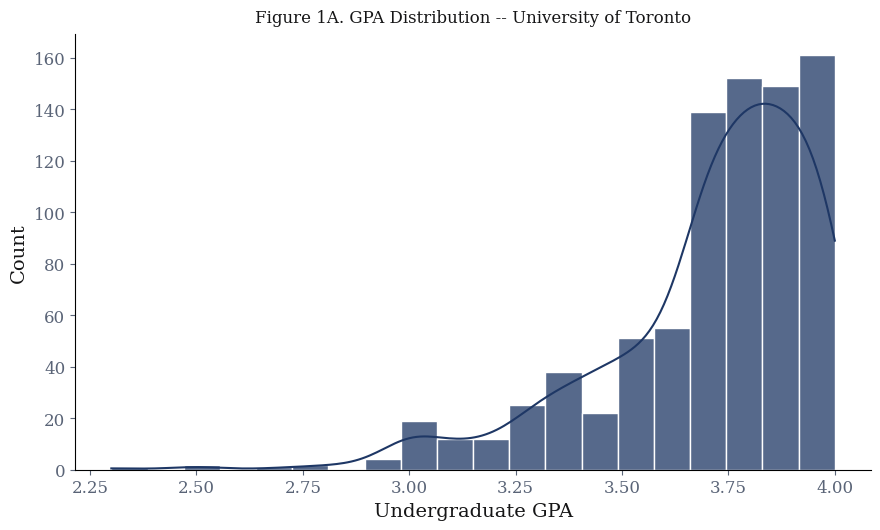

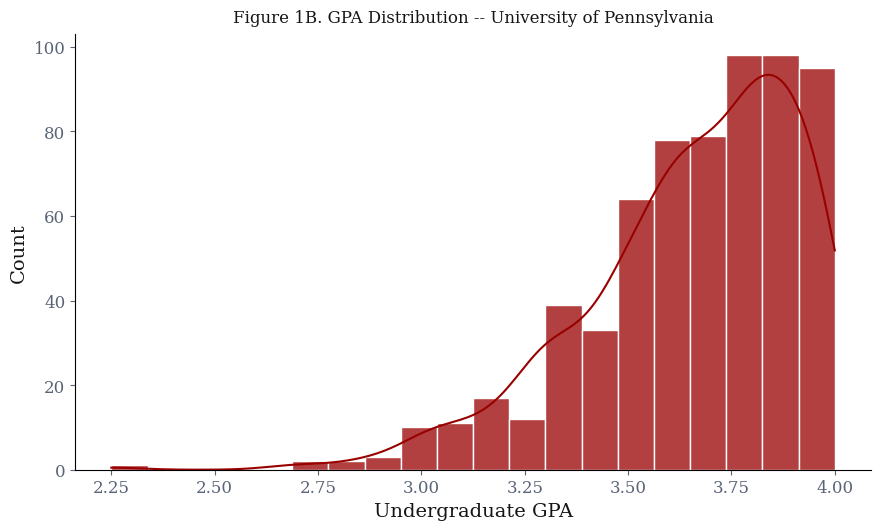

In [16]:
import plotting as plot
plot.plot_gpa_histogram(uoft_clean,  'Figure 1A. GPA Distribution -- University of Toronto',  color=config.UOFT)
plot.plot_gpa_histogram(upenn_clean, 'Figure 1B. GPA Distribution -- University of Pennsylvania', color=config.UPENN)


_Figure 2_ splits the distribution by admission outcome. The key observation is how much the accepted and rejected points overlap. GPA does shift the accepted curve to the right, but the overlap is wide -- a substantial fraction of 3.9 GPA applicants, even notable number of 4.0 applicants are rejected, and a noticeable fraction of 3.4 GPA applicants are accepted. Based on just this, GPA is a condition that improves odds, not one that determines outcomes.

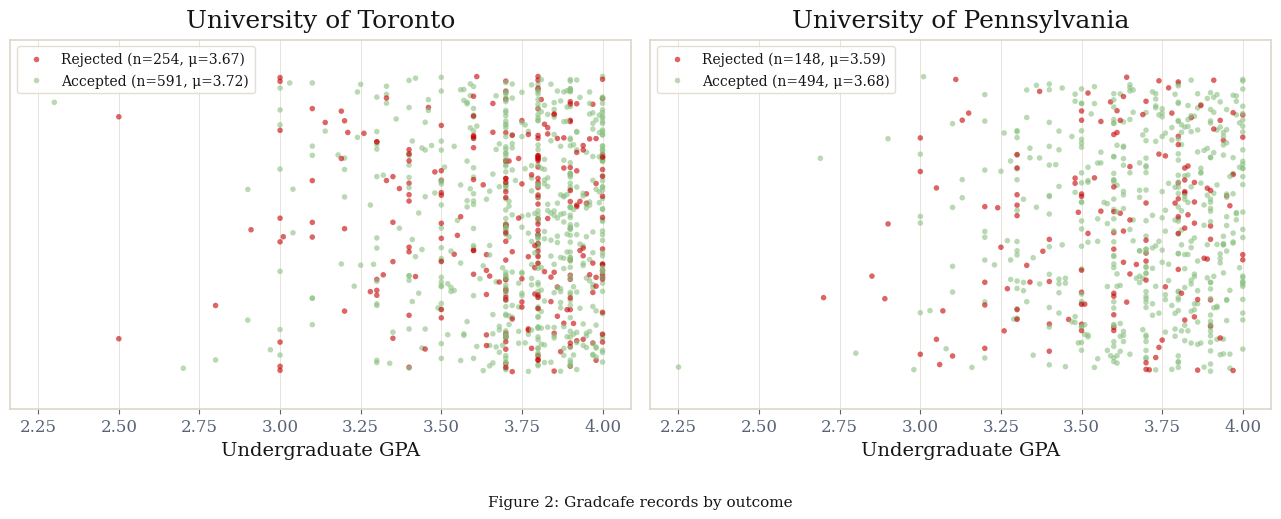

In [17]:
plot.plot_gpa_by_outcome(uoft_clean, upenn_clean)


_Figure 3_ translates this into acceptance rates within GPA bins. Both schools show a clear monotonic increase across bins, but even in the 3.75-4.0 range the rate falls well short of 100% acceptance.

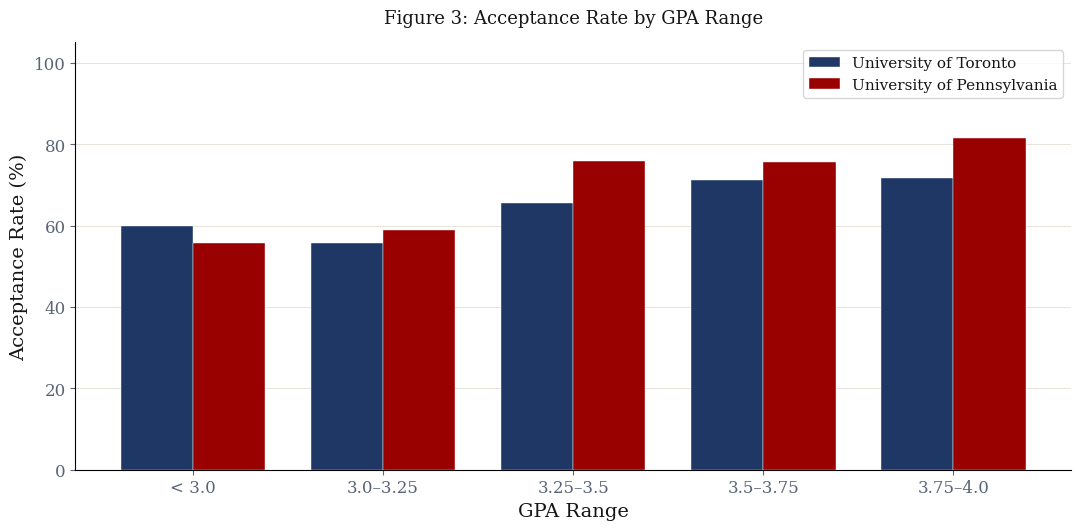

In [18]:
plot.plot_acceptance_by_gpa_range(df_range)

Query 3 data shows the average accepted GPA at UofT is 0.05 points higher than the rejected average (3.72 vs. 3.67). UPenn shows a relatively wider gap of 0.09 points (3.68 vs. 3.59). Figure 3 illustrates the practical effect of this difference. UPenn's acceptance rate scales aggressively with higher GPAs, moving from roughly 50% in the lowest tier to over 80% in the highest. UofT displays a relatively flatter distribution. Its acceptance rates remain relatively static and hover between 50% and 70% across all GPA ranges. This loosely suggests GPA may play a stronger differentiating role at UPenn within the GradCafe sample.

### 3.4 Reporting Bias: What GradCafe Gets Wrong

Query 2 produces implied acceptance rates from GradCafe records that are far above what the institutions actually report. The chart below compares these against the rates computed from the official published CSVs initialized in Section 2.2.

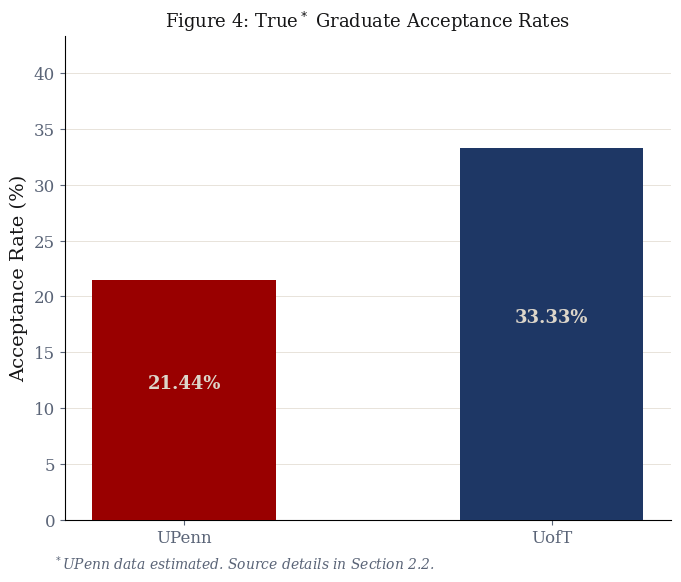

In [19]:
official_rates = plot.true_acceptance_rates(
    'upenn_publicly_av_masters_admissions.csv',
    'uoft_published_graduate_admissions_data.csv'
)

The mechanism behind this gap is straightforward. An applicant who gets into a program they considered a stretch has a strong reason to post: they want to mark their outcome. An applicant who was rejected from a program they expected to get into has little incentive, and many do not. The platform(GradCafe) never sees most rejections. This inherent bias is visualized below in Figure 5.

This matters for how every other result in this project should be read. The GPA range acceptance rates in Section 3.3, the GRE analysis later in 3.6, and the logistic regression probabilities in Section 4.4 all operate on this biased pool.

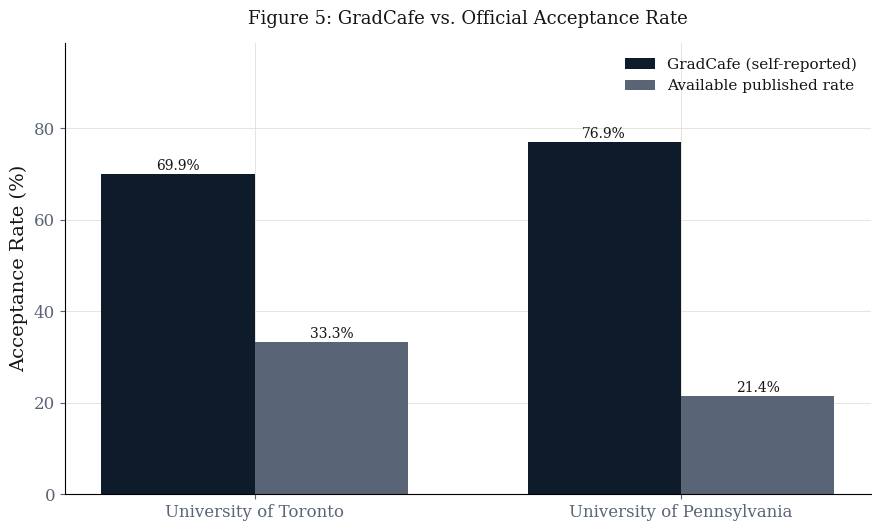

In [20]:
plot.plot_bias_comparison(df_rates)

### 3.5 Trends Over Time

GradCafe records span from the mid-2000s through the 2026 cycle. Tracking the implied acceptance rate by year can reveal whether the GradCafe sample has shifted over time -- either because admissions became more competitive, or because reporting behavior changed (for example, the GRE-optional era<sup>[6]</sup> may have altered who posts), or both.

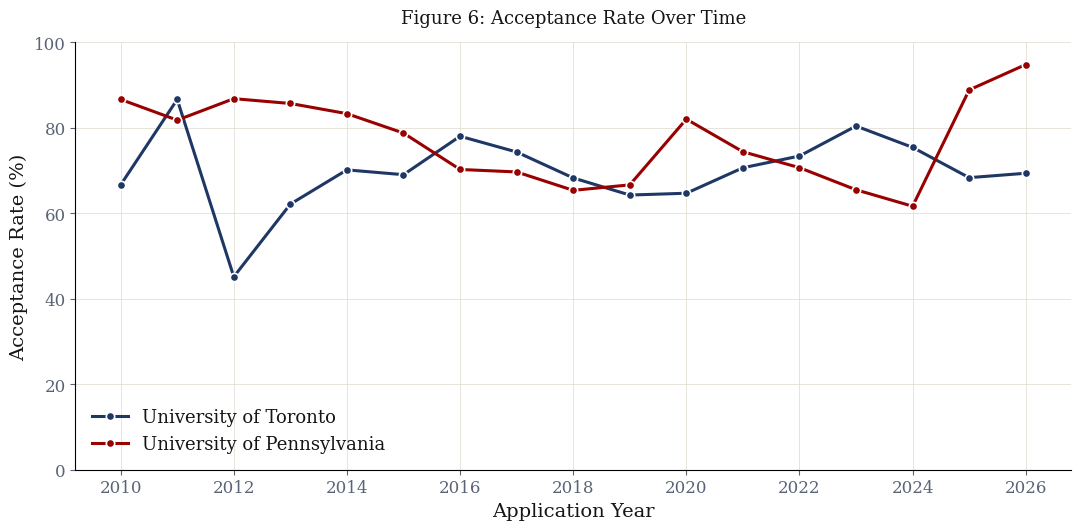

In [21]:
plot.plot_temporal_trends(conn)

Based on _Figure 6_ UPenn's reported acceptance rate shows that it has gotten more competitive from roughly 85% in 2014 to a low near 60% in 2024. This downward trajectory aligns with the general increase in applicants to graduate school<sup>[8]</sup> and subsequent tightening of graduate admission. This was further increased due to the influx of applications during the post-2020 GRE-optional era <sup>[9]</sup>. However, the UPenn data features a massive, sudden spike to nearly 95% in 2025 and 2026. Given the lack of a clear institutional explanation, this spike is unlikely to reflect a true change in selectivity. A more plausible interpretation is that it comes from sampling bias, potentially due to increased usage of self-reported platforms such as GradCafe.

The University of Toronto data is highly erratic. An unexplained crash to 45% occurs in 2012, but the rate quickly recovers. Since 2014, UofT's reported acceptance rate has oscillated between 60% and 80% without a clear directional trend. Ultimately, the extreme fluctuations and the recent UPenn anomalies demonstrate that longitudinal GradCafe data is heavily skewed by changing reporting behaviors.

### 3.6 GRE Submission and Outcomes

GRE data is sparse: only ~18% of UofT records include a score, and ~37% of UPenn records don't have GRE either. While submission rates differ drastically between the two institutions, the data reveals a clear and consistent trend. Submitting a GRE score negatively correlates with admission.

Figure 7 illustrates this inverse relationship. Acceptance rates drop by 10 to 13 percentage points for applicants who provide scores. At the University of Pennsylvania, the acceptance rate falls from 83.5% for non-reporters to 73.1% for reporters. The University of Toronto sees a steeper decline, dropping from 72.3% down to 58.9%.

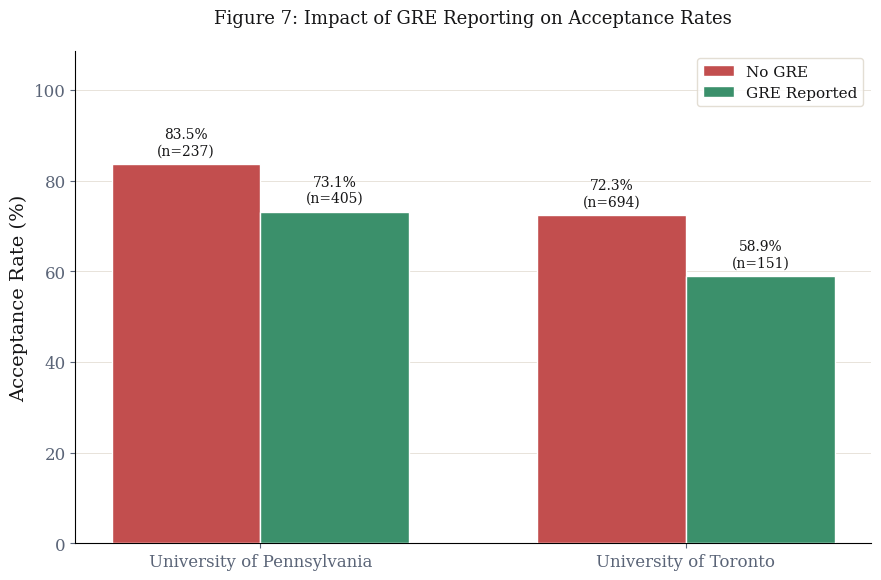

In [22]:
plot.plot_gre_impact(df_gre)

## 4. Predictive Modelling

In [23]:
import predictive_modeling as pm

### 4.1 Motivation and Approach

The analysis so far describes GPA's relationship with admission at the aggregate level -- higher GPA bins have higher acceptance rates in the GradCafe sample. That is a statement about groups. A more precise question is: given a specific applicant's GPA and whether they submitted a GRE score, can we say anything useful about their individual odds?

Given the weak separation between accepted and rejected applicants, this part of the project evaluates whether a simple classifier can extract meaningful individual-level signal with logistic regression. It takes this analysis further by estimating the log-odds of a binary outcome as a linear function of the input features, producing a predicted probability for each applicant and interpretable coefficients for each predictor. It is the standard baseline for binary classification tasks and the natural choice here given the outcome is itself binary and the features are few.

### 4.2 Logistic Regression Model

#### 4.2.1 Model Details

Each institution is modelled independently, thus producing two logistic regression models. The two schools have different GPA distributions, different GradCafe-implied acceptance rates (70% UofT, 77% UPenn), different class imbalances on the GRE inclusion. A shared model would force a common intercept and a common GPA slope across both, neither of which is appropriate when the baseline acceptance probability differs between them. Keeping the models separate means each one is fit to its own distribution and corrected against its own official acceptance rate.

Each model uses two features: `GPA` (continuous and standardized with `StandardScaler`), and `GRE_Reported`, a binary flag for whether a GRE score was submitted. An 80/20 stratified split produces 676 training and 169 test records for UofT, and 513 training and 129 test records for UPenn. `class_weight='balanced'` reweights the loss so the model pays equal attention to accepted and rejected records within each training set. What it cannot fix is that the training data is itself a biased sample: Due to the over-representation of accepted applicants (Section 3.4), the model learns an inflated prior. In the training splits, 70% of UofT records and 77% of UPenn records are acceptances. The model's output probabilities are calibrated to those rates.

In [24]:
models = pm.build_logistic_regression(uoft_clean, upenn_clean)

University of Toronto
  Train: 676  Test: 169  
University of Pennsylvania
  Train: 513  Test: 129  


### 4.2.2 Prior probability adjustment

If we know the true acceptance rate ($\pi_{\text{true}}$) and the model's effective training prior ($\pi_{\text{train}}$), the Saerens et al. <sup>[10]</sup> adjustment re-calibrates predicted probabilities after training to reflect the true class distribution:

$$P_{\text{adj}}(y=1 \mid x) = \frac{P_{\text{train}}(y=1 \mid x) \cdot \dfrac{\pi_{\text{true}}}{\pi_{\text{train}}}}{P_{\text{train}}(y=1 \mid x) \cdot \dfrac{\pi_{\text{true}}}{\pi_{\text{train}}} + P_{\text{train}}(y=0 \mid x) \cdot \dfrac{1-\pi_{\text{true}}}{1-\pi_{\text{train}}}}$$

The adjustment is applied separately per school: UofT uses $\pi_{\text{true}} = 0.3333$ and UPenn uses $\pi_{\text{true}} = 0.2144$, both drawn from the official CSV data discussed in Section 2.2. Because both models were trained with `class_weight='balanced'`, the loss function was rescaled to treat accepted and rejected classes as equally important. This effectively forces the model to learn from a simulated 50/50 composition, making the training prior ($\pi_{\text{train}}$) exactly 0.5 regardless of the raw GradCafe class imbalance.

With this, the model itself does not change, only how we interpret its predicted probabilities does. This correction affects calibration only, not discriminative ability, and therefore does not change the model's performance metrics.


In [25]:
coef_df = pm.get_coefficients_table(models)
display(HTML(coef_df.to_html(index=False)))

Institution,Feature,Coefficient,Odds Ratio
UofT,GPA,0.1968,1.2175
UofT,GRE_Reported,-0.2169,0.8050
UPenn,GPA,0.2509,1.2852
UPenn,GRE_Reported,-0.2308,0.7939


Looking at the coefficients yielded by the models, `GPA` is positive at both schools, this matches the outputs of Queries 3 and 5. The odds ratio of 1.22-1.29 means a one standard-deviation increase in GPA multiplies the estimated admission odds by roughly 1.2-1.3x within each school's pool. Because the features are standardized on different distributions, these coefficients are not numerically comparable across schools.

The negative GRE coefficient is much more interesting and it is already visible in the raw data. Query 6 showed that GRE reporters have _lower_ acceptance rates than non-reporters at both schools. The model is learning a real pattern in the data and the data reveals a clear, consistent trend across both institutions: submitting a GRE score negatively correlates with admission.

The negative coefficient represents a statistical confound rather than a causal relationship and has two plausible explanations that are not mutually exclusive. First, GRE functions as a compensatory signal in modern admissions. Candidates with lower GPAs or weaker qualitative profiles often submit test scores hoping to offset those academic deficits. Because these applicants are already at a structural disadvantage, their lower baseline success rate attaches a negative weight to the GRE variable. Second, GRE reporters are concentrated in pre-2020 cycles before GRE-optional became more common, and those older cycles may carry different baseline dynamics in the GradCafe sample. The coefficient likely reflects a mix of both effects.

### 4.3 Model Performance

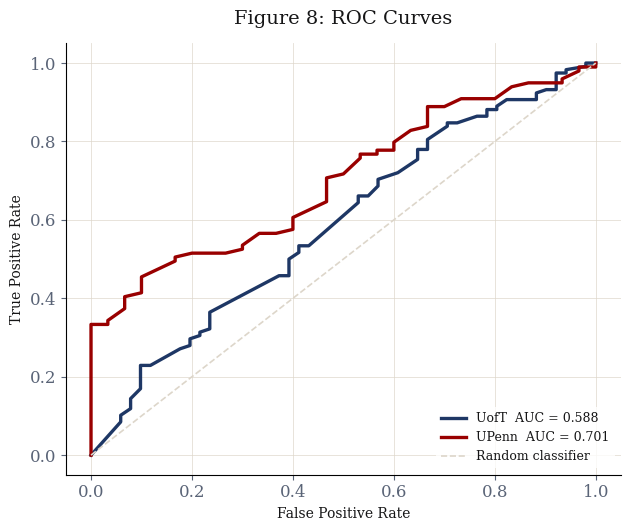

In [26]:
pm.plot_roc_curves(models)

The curves are not directly comparable because the test sets differ in size and class composition, but both are plotted together for legibility.

The UofT AUC of 0.588 indicates near-random discrimination and consistent with what the data already implied: a 0.05-point mean GPA gap between accepted and rejected applicants does not provide much surface for a classifier to work with. One thing to note here is that on the other hand, UPenn's AUC is slightly better at 0.701. This is a strong evidence, based on the available data that UofT weights unmeasured variables much more heavily than UPenn does.

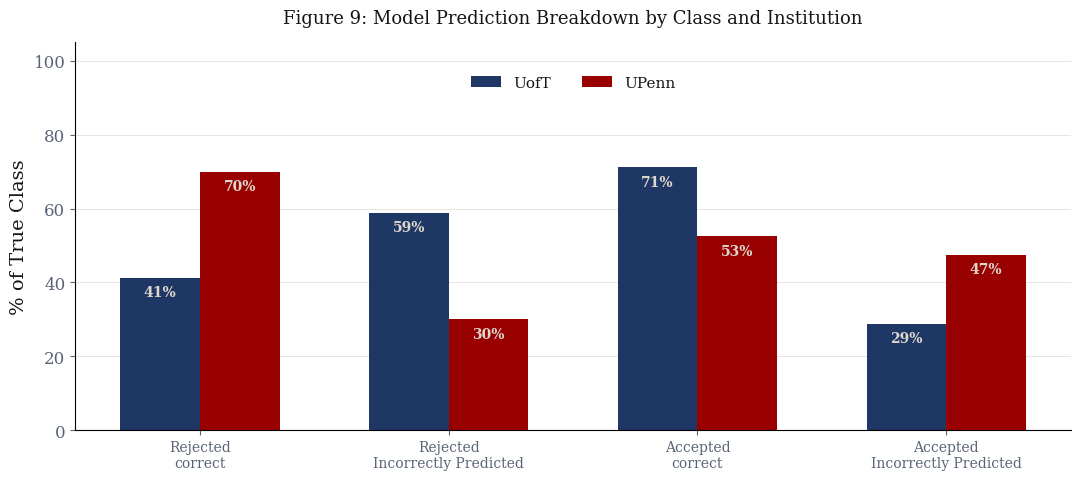

In [27]:
pm.plot_confusion_breakdown(models)

The prediction breakdown reveals where each model fails. At UofT, precision on rejected applicants is 0.38 -- the model is wrong about two-thirds of the time when it predicts rejection here. At UPenn, the pattern inverts: recall on rejected applicants is 0.70, but precision is only 0.31, meaning the model flags many applicants as likely rejected but is wrong most of the time it does so. Neither model is reliable for the class that matters most for individual decision-making.

An in-depth performance metric table is printed in the cell below:


In [28]:
metrics = pm.print_model_metrics(models)

Metric,UofT,UPenn
Accuracy,0.6213,0.5659
ROC-AUC,0.5878,0.7008
Precision (Accepted),0.7368,0.8525
Recall (Accepted),0.7119,0.5253
F1 (Accepted),0.7241,0.6500
Precision (Rejected),0.3818,0.3088
Recall (Rejected),0.4118,0.7000
F1 (Rejected),0.3962,0.4286


### 4.4 Results and Interpretation

The models are evaluated through two applicant profiles that span the realistic range of the data:

- **Applicant A:** GPA 3.92, no GRE submitted. Above the mean accepted GPA at both schools, in the 3.75-4.0 bin where the GradCafe acceptance rate is 71-81%.
- **Applicant B:** GPA 3.44, GRE submitted. Below the mean accepted GPA at both schools, in the 3.25-3.5 bin where the GradCafe acceptance rate is 66-76%.

In [29]:
cases_table = pm.predict_applicant_cases(models)
display(HTML(cases_table[['Profile', 'GradCafe P(admit)', 'Adjusted P(admit)']].to_html(index=False)))

Profile,GradCafe P(admit),Adjusted P(admit)
"A: GPA 3.92, no GRE -- UofT",57.0%,39.8%
"A: GPA 3.92, no GRE -- UPenn",64.2%,32.8%
"B: GPA 3.44, GRE -- UofT",34.4%,20.8%
"B: GPA 3.44, GRE -- UPenn",40.7%,15.7%


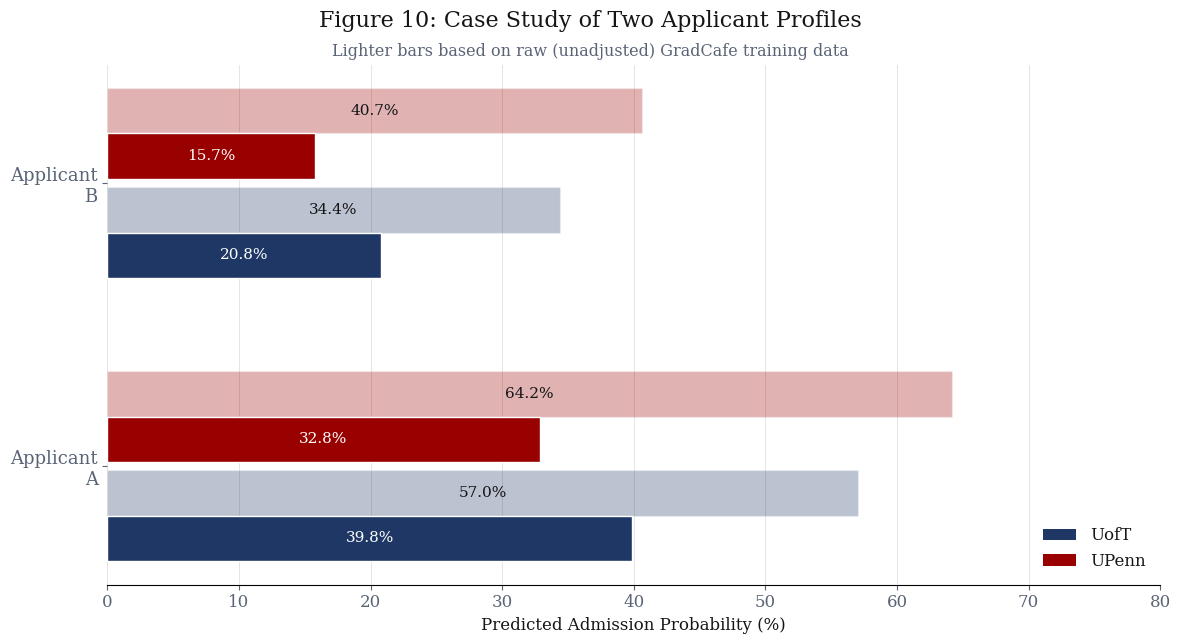

In [30]:
pm.plot_applicant_cases(cases_table)

The raw GradCafe probabilities look a little too optimistic and are not arbitrary -- they are internally consistent with the inflated acceptance rates the model was trained on. A 64.2% raw probability for Applicant A at UofT makes sense in a pool where 70% of posted records are acceptances. The problem is that this number has nothing to do with the odds of getting in; it reflects who chose to post.

After the Saerens adjustment, the numbers look more realistic. Applicant A's probability drops to 39.8% at UofT and 32.8% at UPenn. The  and  percentage point reductions are the exact arithmetic consequence of correcting a 70% implied rate back to 33.3%, and a 77% rate back to 21.4%. A GPA of 3.92 places Applicant A in the 3.75-4.0 bin, which Query 5 showed has the highest acceptance rate in the GradCafe sample at both schools (although not by a lot). Even there, the adjusted probability sits below one-in-five at UofT and below one-in-eight at UPenn. This is consistent with what a 33% and 21% base rate implies for any individual: the vast majority of applicants at any GPA level are rejected, and GPA alone cannot overcome that.

Applicant B's adjusted probabilities are 20.8% at UofT and 15.7% at UPenn. The GRE submission does not help -- the model assigns it a negative weight. At a 3.44 GPA with a GRE score, Applicant B falls below a one-in-ten chance at UofT and below one-in-twenty at UPenn once the prior is corrected.

The adjusted probabilities represent a more accurate estimation of individual odds. These values are consistently lower for UPenn than UofT across both profiles, which is expectedly aligns with the actual institutional selectivity as seen in the official datasets.

## 5. Conclusions

**Q1: GPA and admission probability.** Higher GPA is associated with higher acceptance rates across GPA bins at both schools, and the logistic regression assigns a GPA odds ratio of 1.22(at UofT) and 1.29(at UPenn). The relationship is real but modest. The KDE distributions show GPA has a positive but weak association with admission, with substantial overlap between accepted and rejected applicants even at high GPA levels.

**Q2: Institutional Selectivity and GPA Profiles.** 
Counterintuitively, The self-reported records imply UPenn is easier to enter than UofT. The true official rates prove the opposite. Beyond the baseline reporting bias, the data exposes a harsh reality about elite graduate admissions: GPA is a prerequisite, not a differentiator. Figure 2 shows massive applicant clustering above a 3.5 GPA. The difference between accepted and rejected averages is practically statistical noise. UofT accepted profiles average 3.72 against rejected averages of 3.67. UPenn accepted profiles actually carry a lower average (3.68) than UofT's, despite UPenn being the more selective institution. 
Selectivity is not defined by strict GPA cutoffs. Beyond a certain threshold, GPA appears to play a limited role in differentiating applicants, with other factors likely driving decisions. It's most likely one or more of-- letters of recommendations, prior experiences and statements of intent or interview if applicable. The odds ratios quantify exactly how weak GPA becomes at the top of the pool. Because the features using in the model are standard-scaled, the odds ratio represents the impact of a full standard deviation increase in GPA. Outperforming the average applicant by a massive margin only multiplies the odds of admission by 1.22 at UofT and 1.28 at UPenn.

**Q3: GRE and outcomes.** The GRE_Reported coefficient is negative at both schools independently. Query 6 showed the same pattern in the raw data: GRE reporters have lower acceptance rates than non-reporters at both institutions. 

**Q4: Predictive limits.** The per-school model performance (AUCs: 0.588 for UofT and 0.701 for UPenn) indicates limited predictive power. After adjusting for true acceptance rates, even strong applicants have low probabilities, reinforcing that GPA and GRE alone are insufficient for reliable prediction.

What this project ultimately demonstrates is that GradCafe is not an admissions predictor -- it is a social journal of who chose to post. Every analysis here, from the acceptance rates based on GPA ranges to the logistic regression probabilities, operates on a sample so distorted by self-selection that the absolute numbers are not trustworthy in isolation. What the data can support are comparisons: UPenn is more selective than UofT, GPA has a weak positive association with admission, and GRE submission carries no positive signal in the current era. These relative findings survive the bias because the distortion runs in roughly the same direction across groups. The adjusted case studies make the practical takeaway concrete: a 3.92 GPA, which sits at the top of the GradCafe distribution, still yields adjusted admission odds of only 39.8% at UofT and 32.8% at UPenn once the sample is grounded in official rates. GradCafe is most useful as a source of timing data and program-level signal, not as a basis for predicting whether any individual applicant will be admitted.

## 6. Limitations

**UPenn's unknown official rates.** UPenn is a private institution and does not publicly report graduate acceptance rates at the university level. The 21.44% figure used in this project is a weighted estimate derived from programs that voluntarily publish their admissions data. Penn's graduate offerings span law, medicine, social work, education, design, and business, each with its own admissions dynamics. The true university-wide Master's acceptance rate is likely higher than 21.44%, and there is no way to know by how much. This means the Saerens adjustment for UPenn is itself based on an approximation, and the adjusted probabilities for UPenn applicants should be read as lower bounds on realistic admission chances rather than point estimates.

**UofT's aggregated official rates.** UofT does publish graduate acceptance rates, but it distinguishes between research-stream and professional Master's programs, which behave very differently. Research Master's programs are considerably more selective(28.4% vs 39.5%); professional programs admit larger cohorts with different evaluation criteria. This project uses an aggregate rate across both streams, which has no clean interpretation. It understates selectivity for research-track applicants and overstates it for professional-track ones. The GradCafe pool itself is similarly mixed, with no way to reliably separate the two streams from the program name alone.

**Self-selection bias.** As mentioned in 4.2.1, the Saerens adjustment corrects the calibration of predicted probabilities but does not fix the training data itself. The model's weights, its learned GPA coefficient, and its class boundaries are all estimated from a sample where accepted applicants are dramatically over-represented. GradCafe's implied acceptance rate is 69.2% for UofT and 77.0% for UPenn against official rates of 33.3% and 21.4% respectively, overestimations of 35.9 and 55.5 percentage points. Every aggregate statistic derived from GradCafe in the analysis sections of this paper, including the acceptance rates by  GPA range and the GRE submission comparison, should be read as an inflated upper bound rather than a population estimate.

**Smaller training sets per school.** Splitting the data by institution rather than pooling it means each model is trained on roughly half the records. Because the UPenn dataset is smaller and contains a different baseline class composition than the UofT dataset, its feature weights are more sensitive to sampling noise. Direct comparisons between the admission dynamics of the two schools are therefore not precise.

**Discarded decision types.** GradCafe's decision field is not binary. Applicants also report waitlists, interviews, and application withdrawals. This project drops every row that does not clearly start with "Accepted" or "Rejected." Waitlisted applicants are excluded entirely, which may introduce additional directional bias if waitlists correlate with GPA in a way that differs from the accepted and rejected pools.

**Scope of the logistic regression.** Logistic regression is an appropriate model for a binary classification task with interpretable coefficients, but it assumes a linear relationship between the log-odds of admission and the features. The true decision boundary is almost certainly not linear in GPA: admissions committees likely apply something closer to a threshold function, where applicants below a program's floor are screened out early and those above it are evaluated on other criteria. A linear log-odds model cannot capture this, and the smooth probability curves it produces may give a false impression of continuity in a process that is in practice more discontinuous. The low AUC confirms this indirectly: the features available simply do not contain enough information to recover the true decision boundary regardless of the model's functional form. However that is what this project is about--  this lack of signal is the core finding of the project. It confirms that these quantitative metrics are far less decisive than crowdsourced narratives imply and gives us a metric of by exactly how much.

**Non-standard library.** The scraper uses `cloudscraper`, which is not covered in CSC271 and thus, generative artificial intelligence was used in the scraping function. Pre-scraped CSV files are included so the notebook runs end-to-end without re-scraping. 

## References

- [1] Cloudflare, "What happens in a TLS handshake?" [Online]. Available: https://www.cloudflare.com/en-ca/learning/ssl/what-happens-in-a-tls-handshake/
- [2] VeNoMouS, "cloudscraper," Version 1.2.71, 2023. [Online]. Available: https://pypi.org/project/cloudscraper/
- [3] University of Toronto, "Facts & Figures: Students," Institutional Research and Data Governance, 2024. [Online]. Available: https://data.utoronto.ca/data-and-reports/facts-and-figures/facts-and-figures-students/
- [4] University of Pennsylvania, "CIS Graduate Program Admissions Statistics." [Online]. Available: https://www.cis.upenn.edu/graduate/admission-statistics/

- [5] University of Pennsylvania GRASP Laboratory, "Admission Statistics." [Online]. Available: https://www.grasp.upenn.edu/academics/admission-stats/
- [6] Peterson's, "Peterson's," [Online]. Available: https://www.petersons.com/
- [7] K. Langin, "A wave of graduate programs drops the GRE application requirement," Science, 2019. [Online]. Available: https://www.science.org/content/article/wave-graduate-programs-drop-gre-application-requirement
- [8] National Center for Education Statistics, "Graduate Degree Fields," Condition of Education, U.S. Department of Education, 2024. [Online]. Available: https://nces.ed.gov/programs/coe/indicator/ctb/graduate-degree-fields
- [9] Council of Graduate Schools, "Graduate Enrollment and Degrees: 2010 to 2020," 2021. [Online]. Available: https://cgsnet.org/wp-content/uploads/2022/02/CGS_GED20_Report_final_v2-2.pdf
- [10] M. Saerens, P. Latinne, and C. Decaestecker, "Adjusting the outputs of a classifier to new a priori probabilities: a simple procedure," Neural Computation, vol. 14, no. 1, pp. 21–41, 2002. [Online]. Available: https://doi.org/10.1162/089976602753284446